In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

正在加载 MNIST 数据集...
开始追踪前 300 步的训练动态...
正在计算功能连接(FC)演化历史...
正在绘制 4 联图...


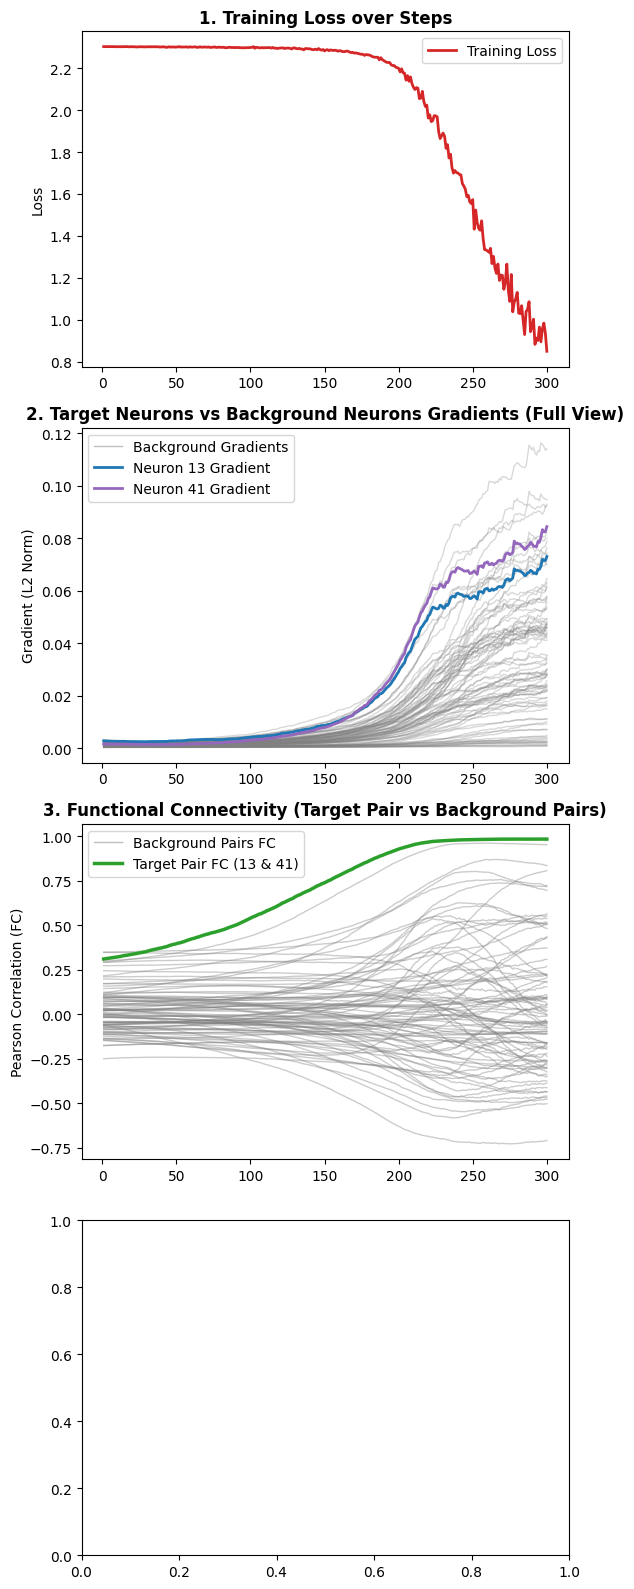

In [2]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)                
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False    

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10):
        super(MLP, self).__init__()
        self.linear_layers = nn.ModuleList()
        layers = []
        
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(nn.ReLU())
            current_dim = h_dim
        
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        
        self.network = nn.Sequential(*layers)
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)
    
    def get_hidden_activations(self, x):
        x = x.view(x.size(0), -1)
        activations = []
        for layer in self.network:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x.clone())
        return activations

def load_standard_mnist(batch_size=256):
    print("正在加载 MNIST 数据集...")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

def train_and_track_gradients(model, train_loader, max_steps=300):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.05)
    # optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    model_states, losses = [], []
    neuron_grad_norms = [] 
    step_count = 0
    
    model.train()
    print(f"开始追踪前 {max_steps} 步的训练动态...")
    
    # 准备固定的评估数据用于后续精准计算 FC
    eval_samples = []
    class_counts = {i: 0 for i in range(10)}
    for data, targets in train_loader:
        for i in range(len(targets)):
            label = targets[i].item()
            if class_counts[label] < 50:
                eval_samples.append(data[i])
                class_counts[label] += 1
        if len(eval_samples) == 500:
            break
    eval_samples = torch.stack(eval_samples).to(device)

    while step_count < max_steps:
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # 提取第一层的梯度矩阵 (100x784)
            layer1_grad = model.linear_layers[0].weight.grad.detach()
            grad_l2 = torch.norm(layer1_grad, p=2, dim=1).cpu().numpy()
            neuron_grad_norms.append(grad_l2)
            
            optimizer.step()
            losses.append(loss.item())
            
            # 每一步都保存状态，确保数据完美对齐
            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            model_states.append(state)
            
            step_count += 1
            if step_count >= max_steps:
                break
                
    return model_states, losses, np.array(neuron_grad_norms), eval_samples

def smooth_curve(points, factor=0.95):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

def analyze_and_plot_dynamics(models, losses, grad_norms, eval_samples):
    print("正在计算功能连接(FC)演化历史...")
    template_model = MLP(input_size=784, hidden_dims=[100, 100])
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template_model.to(device)
    
    fc_history = []
    
    # 1. 计算每一步的完整 FC 矩阵
    for i in range(len(models)):
        template_model.load_state_dict(models[i])
        template_model.eval()
        
        with torch.no_grad():
            activations = template_model.get_hidden_activations(eval_samples)
            layer1_act = activations[0].cpu().numpy()
            FC = np.corrcoef(layer1_act.T)
            FC = np.nan_to_num(FC)
            np.fill_diagonal(FC, 0) # 排除自相关
            fc_history.append(FC)
            
    fc_history = np.array(fc_history) # 形状: (steps, 100, 100)
    
    # 2. 找到在整个训练初期出现过最高 FC 的那对“先锋神经元”
    max_fc_idx = np.unravel_index(np.argmax(fc_history), fc_history.shape)
    peak_step, pioneer_i, pioneer_j = max_fc_idx
    
    # 3. 随机抽取背景神经元和背景神经元对
    all_neurons = set(range(100))
    all_neurons -= {pioneer_i, pioneer_j}
    background_neurons = random.sample(list(all_neurons), 90)
    # 将背景神经元两两配对，用于展示普通的 FC 演化
    bg_pairs = [(background_neurons[i], background_neurons[i+1]) for i in range(0, 89, 1)]

    # 4. 提取对应的 FC 演化曲线
    pioneer_fc_curve = fc_history[:, pioneer_i, pioneer_j]
    
    # 为梯度添加轻度平滑以提升视觉清晰度
    # def smooth_curve(array, w=20):
    #     return np.convolve(array, np.ones(w)/w, mode='same')
    
    pioneer_1_grad = smooth_curve(grad_norms[:, pioneer_i])
    pioneer_2_grad = smooth_curve(grad_norms[:, pioneer_j])
    
    steps_all = np.arange(1, len(losses) + 1)
    
    print("正在绘制 4 联图...")
    # 5. 开始绘制 4 个子图
    fig, axs = plt.subplots(4, 1, figsize=(6, 16))
    fig.subplots_adjust(hspace=0.3)
    
    # --- 图 1：Loss 曲线 ---
    axs[0].plot(steps_all, losses, color='tab:red', linewidth=2, label='Training Loss')
    axs[0].set_title('1. Training Loss over Steps', fontsize=12, fontweight='bold')
    axs[0].set_ylabel('Loss')
    axs[0].legend(loc='upper right')
    
    # --- 图 2：梯度对比曲线 (全景) ---
    for bg_idx in background_neurons:
        bg_grad = smooth_curve(grad_norms[:, bg_idx])
        axs[1].plot(steps_all, bg_grad, color='gray', alpha=0.3, linewidth=1)
    axs[1].plot([], [], color='gray', alpha=0.5, linewidth=1, label='Background Gradients')
    
    axs[1].plot(steps_all, pioneer_1_grad, color='tab:blue', linewidth=2, label=f'Neuron {pioneer_i} Gradient')
    axs[1].plot(steps_all, pioneer_2_grad, color='tab:purple', linewidth=2, label=f'Neuron {pioneer_j} Gradient')
    axs[1].set_title('2. Target Neurons vs Background Neurons Gradients (Full View)', fontsize=12, fontweight='bold')
    axs[1].set_ylabel('Gradient (L2 Norm)')
    axs[1].legend(loc='best')
    
    # --- 图 3：功能连接 (FC) 对比曲线 ---
    for bg_u, bg_v in bg_pairs:
        bg_fc = fc_history[:, bg_u, bg_v]
        axs[2].plot(steps_all, bg_fc, color='gray', alpha=0.4, linewidth=1)
    axs[2].plot([], [], color='gray', alpha=0.5, linewidth=1, label='Background Pairs FC')
    
    axs[2].plot(steps_all, pioneer_fc_curve, color='tab:green', linewidth=2.5, label=f'Target Pair FC ({pioneer_i} & {pioneer_j})')
    axs[2].set_title('3. Functional Connectivity (Target Pair vs Background Pairs)', fontsize=12, fontweight='bold')
    axs[2].set_ylabel('Pearson Correlation (FC)')
    axs[2].legend(loc='upper left')
    
    # --- 图 4：梯度对比曲线 (前期放大展示) ---
    # zoom_steps = min(150, len(losses)) # 默认放大前 150 步
    # for bg_idx in background_neurons:
    #     bg_grad = smooth_curve(grad_norms[:, bg_idx])
    #     axs[3].plot(steps_all[:zoom_steps], bg_grad[:zoom_steps], color='gray', alpha=0.3, linewidth=1)
    
    # axs[3].plot(steps_all[:zoom_steps], pioneer_1_grad[:zoom_steps], color='tab:blue', linewidth=2.5, label=f'Neuron {pioneer_i} Gradient')
    # axs[3].plot(steps_all[:zoom_steps], pioneer_2_grad[:zoom_steps], color='tab:purple', linewidth=2.5, label=f'Neuron {pioneer_j} Gradient')
    # axs[3].set_title(f'4. Early Stage Gradients Zoom-In (First {zoom_steps} steps)', fontsize=12, fontweight='bold')
    # axs[3].set_xlabel('Training Steps (Batch)')
    # axs[3].set_ylabel('Gradient (L2 Norm)')
    # axs[3].legend(loc='upper right')

    # for ax in axs:
        # ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    # plt.savefig('./fig/gradient_fc_dynamics.pdf', format='pdf')
    plt.show()

if __name__ == '__main__':
    set_seed(0)
    train_loader = load_standard_mnist(batch_size=256)
    model = MLP(input_size=784, hidden_dims=[100, 100], num_classes=10)
    
    models_states, losses, grad_norms, eval_samples = train_and_track_gradients(model, train_loader, max_steps=300)
    analyze_and_plot_dynamics(models_states, losses, grad_norms, eval_samples)

正在加载 MNIST 数据集...
开始训练并记录前 1000 步动态...
开始深入分析，构建完整故事...
计算功能连接(FC)演化过程...
先锋神经元对: (13, 41)
计算关键步的误差信号与激活方差...
计算神经元激活频率 (ReLU 闸门效应)...
绘制精简版前半部分故事图...


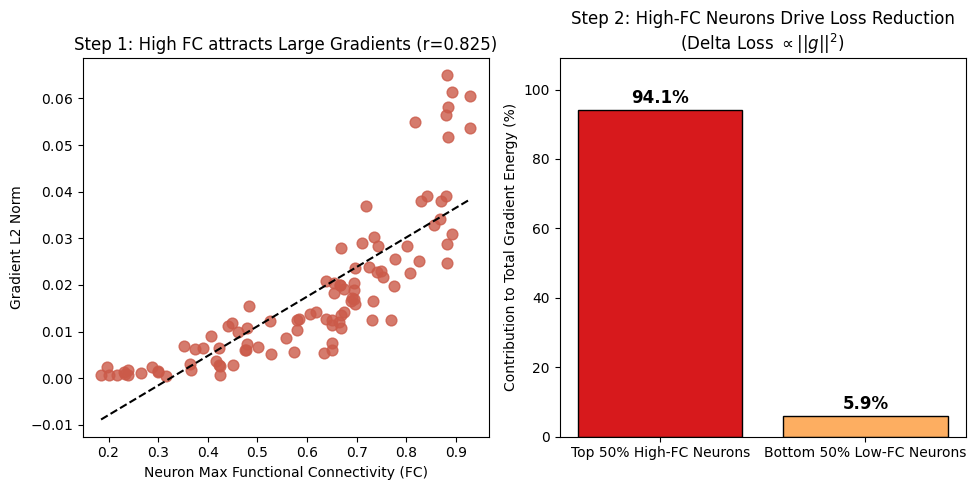

In [3]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import random
import warnings

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10):
        super(MLP, self).__init__()
        self.linear_layers = nn.ModuleList()
        layers = []
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(nn.ReLU())
            current_dim = h_dim
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

    def get_hidden_activations(self, x):
        x = x.view(x.size(0), -1)
        activations = []
        for layer in self.network:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x.clone())
        return activations

def load_standard_mnist(batch_size=256):
    print("正在加载 MNIST 数据集...")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

def train_and_collect_data(model, train_loader, max_steps=250):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.05)
    
    model_states, losses, neuron_grad_norms = [], [], []
    step_count = 0
    print(f"开始训练并记录前 {max_steps} 步动态...")
    model.train()
    
    # 准备固定评估数据（含标签），用于后续 FC 和梯度分解
    eval_samples, eval_targets = [], []
    class_counts = {i: 0 for i in range(10)}
    for data, targets in train_loader:
        for img, label in zip(data, targets):
            lbl = label.item()
            if class_counts[lbl] < 50:
                eval_samples.append(img)
                eval_targets.append(label)
                class_counts[lbl] += 1
        if len(eval_samples) >= 500:
            break
    eval_samples = torch.stack(eval_samples).to(device)
    eval_targets = torch.tensor(eval_targets).to(device)
    
    # 设定关键分析步
    critical_step = 150
    saved_grad_matrix = None   # 用于保存第 critical_step 的完整权重梯度
    
    while step_count < max_steps:
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # 记录第一层每个神经元的梯度 L2 范数
            layer1_grad = model.linear_layers[0].weight.grad.detach()
            grad_l2 = torch.norm(layer1_grad, p=2, dim=1).cpu().numpy()
            neuron_grad_norms.append(grad_l2)
            
            # 在关键步保存完整梯度矩阵（用于后续分析梯度方向协同）
            if step_count == critical_step:
                saved_grad_matrix = layer1_grad.cpu().clone()
            
            optimizer.step()
            losses.append(loss.item())
            
            # 每2步保存一次模型状态
            if step_count % 2 == 0:
                state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                model_states.append(state)
            
            step_count += 1
            if step_count >= max_steps:
                break
    
    return (model_states, losses, np.array(neuron_grad_norms),
            eval_samples, eval_targets, saved_grad_matrix)

def detailed_analysis(models, losses, grad_norms, eval_samples, eval_targets, saved_grad_matrix):
    print("===============================")
    print("开始深入分析，构建完整故事...")
    device = eval_samples.device
    template_model = MLP(input_size=784, hidden_dims=[100, 100]).to(device)
    
    # ---------- 1. 计算功能连接演化，定位先锋对 ----------
    print("计算功能连接(FC)演化过程...")
    fc_history = []
    for state in models:
        template_model.load_state_dict(state)
        template_model.eval()
        with torch.no_grad():
            act = template_model.get_hidden_activations(eval_samples)[0].cpu().numpy()  # (500, 100)
            FC = np.corrcoef(act.T)
            FC = np.nan_to_num(FC)
            np.fill_diagonal(FC, 0)
            fc_history.append(FC)
    fc_history = np.array(fc_history)  # (num_states, 100, 100)
    
    # 找到整个早期出现的最高 FC 神经元对
    max_fc_idx = np.unravel_index(np.argmax(fc_history), fc_history.shape)
    _, pioneer_i, pioneer_j = max_fc_idx
    print(f"先锋神经元对: ({pioneer_i}, {pioneer_j})")
    
    # 计算每个神经元在所有保存步中的最大 FC（用于横截面分析）
    all_neuron_max_fcs = [np.max(fc, axis=1) for fc in fc_history]  # 每个状态一个 (100,) 向量
    
    # ---------- 2. 关键步 (150) 的深入分解 ----------
    critical_step = 200
    # 因为每2步保存一次，索引为 critical_step // 2
    model_idx = critical_step // 2
    critical_state = models[model_idx]
    
    template_model.load_state_dict(critical_state)
    template_model.eval()
    
    # 获取关键步的 FC 矩阵和每个神经元的最大 FC
    with torch.no_grad():
        act_c = template_model.get_hidden_activations(eval_samples)[0].cpu().numpy()
        fc_critical = np.corrcoef(act_c.T)
        np.fill_diagonal(fc_critical, 0)
        max_fc_critical = np.max(fc_critical, axis=1)  # 每个神经元最大 FC
    
    # 获取关键步的梯度范数（训练时记录的）
    grad_l2_critical = grad_norms[critical_step]  # (100,)
    
    # 使用评估样本进行一次反向传播，获取：
    #   - 误差信号强度：∂L/∂h1 的范数
    #   - 权重梯度矩阵（与训练梯度一致）
    print("计算关键步的误差信号与激活方差...")
    template_model.train()  # 保持 dropout 等一致（本模型没有），仅为了梯度计算
    x_eval = eval_samples.clone().requires_grad_(False)
    t_eval = eval_targets
    
    # 前向传播，保留中间激活 h1
    x_flat = x_eval.view(x_eval.size(0), -1)
    h1 = template_model.linear_layers[0](x_flat)
    h1_relu = torch.relu(h1)
    # 继续完成剩余前向
    out = template_model.network[2:](h1_relu)  # 剩下的 sequential: [Linear, ReLU, Linear]
    loss = nn.CrossEntropyLoss()(out, t_eval)
    
    # 反向传播得到 h1_relu 和第一层权重的梯度
    err_grad, weight_grad = torch.autograd.grad(
        loss, [h1_relu, template_model.linear_layers[0].weight],
        retain_graph=True, create_graph=False
    )
    # 误差信号强度：每个神经元在所有样本上梯度的 L2 范数
    error_signal_strength = torch.norm(err_grad, p=2, dim=0).cpu().numpy()  # (100,)
    # 第一层权重梯度 (100, 784)
    first_layer_grad = weight_grad.detach().cpu()
    
    # 激活方差：每个神经元在500个样本上的方差
    h1_relu_np = h1_relu.detach().cpu().numpy()
    activation_var = np.var(h1_relu_np, axis=0)  # (100,)
    
    # 梯度方向协同：计算每对神经元的梯度余弦相似度
    grad_matrix = first_layer_grad.numpy()  # (100, 784)
    # 归一化
    grad_normed = grad_matrix / (np.linalg.norm(grad_matrix, axis=1, keepdims=True) + 1e-10)
    cosine_sim_matrix = np.dot(grad_normed, grad_normed.T)  # (100, 100)
    np.fill_diagonal(cosine_sim_matrix, 0)
    
    # 先锋对的梯度余弦相似度
    pioneer_cosine = cosine_sim_matrix[pioneer_i, pioneer_j]
    
    # 随机选取90个背景神经元并配对，计算余弦相似度分布
    all_neurons = set(range(100))
    all_neurons -= {pioneer_i, pioneer_j}
    background_neurons = random.sample(sorted(all_neurons), 90)
    bg_pairs = [(background_neurons[i], background_neurons[i+1]) for i in range(0, 89, 2)]
    bg_cosines = [cosine_sim_matrix[u, v] for u, v in bg_pairs]
    
    # ---------------- 提取并计算额外指标 ----------------
    print("计算神经元激活频率 (ReLU 闸门效应)...")
    # 计算每个神经元在 500 个样本中激活（值大于 0）的比例
    activation_rate = np.mean(h1_relu_np > 0, axis=0)

    # 预计算绘图用的 x 轴趋势线范围，避免代码重复
    x_fc = np.linspace(max_fc_critical.min(), max_fc_critical.max(), 50)
    x_err = np.linspace(error_signal_strength.min(), error_signal_strength.max(), 50)
    x_act = np.linspace(activation_rate.min(), activation_rate.max(), 50)

    # # ---------------- 3. 绘制9联图叙述完整故事 ----------------
    # print("绘制完整机制验证图(3x3)...")
    # fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    # ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = axes
    
    # # --- 图 A: 训练损失曲线 ---
    # ax1.plot(losses, color='tab:red', linewidth=1.5)
    # ax1.axvline(x=critical_step, color='black', linestyle='--', label=f'Critical step {critical_step}')
    # ax1.set_xlabel('Steps (batches)')
    # ax1.set_ylabel('Training Loss')
    # ax1.set_title('A. Training Loss')
    # ax1.legend()
    
    # # --- 图 B: 先锋对 vs 背景神经元的梯度演化 ---
    # steps_array = np.arange(1, len(grad_norms)+1)
    # bg_sample = random.sample(range(100), 10)
    # for bg in bg_sample:
    #     ax2.plot(steps_array, grad_norms[:, bg], color='gray', alpha=0.4, linewidth=0.8)
    # ax2.plot(steps_array, grad_norms[:, pioneer_i], color='tab:blue', linewidth=2, label=f'Neuron {pioneer_i}')
    # ax2.plot(steps_array, grad_norms[:, pioneer_j], color='tab:purple', linewidth=2, label=f'Neuron {pioneer_j}')
    # ax2.set_xlabel('Steps (batches)')
    # ax2.set_ylabel('Gradient L2 Norm')
    # ax2.set_title('B. Pioneer vs Background Gradients')
    # ax2.legend()
    
    # # --- 图 C: 梯度方向协同：先锋对 vs 随机对 ---
    # ax3.bar(['Pioneer Pair\n({},{})'.format(pioneer_i, pioneer_j),
    #          'Random Pairs\n(mean ± std)'],
    #         [pioneer_cosine, np.mean(bg_cosines)],
    #         yerr=[0, np.std(bg_cosines)],
    #         color=['#fdae61', '#abd9e9'], edgecolor='black')
    # ax3.set_ylabel('Gradient Cosine Similarity')
    # ax3.set_title('C. Gradient Alignment: Pioneer vs Random')

    # # --- 图 D: 最大FC vs 激活方差 ---
    # r4, p4 = stats.pearsonr(max_fc_critical, activation_var)
    # ax4.scatter(max_fc_critical, activation_var, c='#7b3294', alpha=0.8, s=50)
    # m4, b4 = np.polyfit(max_fc_critical, activation_var, 1)
    # ax4.plot(x_fc, m4*x_fc + b4, 'k--', linewidth=1.5)
    # ax4.set_xlabel('Neuron Max FC')
    # ax4.set_ylabel('Activation Variance')
    # ax4.set_title(f'D. Max FC vs Activation Variance (r={r4:.3f})')

    # # --- 图 E: 最大FC vs 激活频率 (Gate 1) ---
    # r_g1, p_g1 = stats.pearsonr(max_fc_critical, activation_rate)
    # ax5.scatter(max_fc_critical, activation_rate, c='#8b7065', alpha=0.8, s=50)
    # m_g1, b_g1 = np.polyfit(max_fc_critical, activation_rate, 1)
    # ax5.plot(x_fc, m_g1*x_fc + b_g1, 'k--', linewidth=1.5)
    # ax5.set_xlabel('Neuron Max FC')
    # ax5.set_ylabel('Activation Rate (Frequency h>0)')
    # ax5.set_title(f'E. Max FC vs Activation Rate (r={r_g1:.3f})')

    # # --- 图 F: 激活频率 vs 误差信号强度 (Gate 2) ---
    # r_g2, p_g2 = stats.pearsonr(activation_rate, error_signal_strength)
    # ax6.scatter(activation_rate, error_signal_strength, c='#e41a1c', alpha=0.8, s=50)
    # m_g2, b_g2 = np.polyfit(activation_rate, error_signal_strength, 1)
    # ax6.plot(x_act, m_g2*x_act + b_g2, 'k--', linewidth=1.5)
    # ax6.set_xlabel('Activation Rate (Frequency h>0)')
    # ax6.set_ylabel('Error Signal Strength')
    # ax6.set_title(f'F. Activation Rate vs Error Signal (r={r_g2:.3f})')

    # # --- 图 G: 最大FC vs 误差信号强度 ---
    # r2, p2 = stats.pearsonr(max_fc_critical, error_signal_strength)
    # ax7.scatter(max_fc_critical, error_signal_strength, c='#f6af43', alpha=0.8, s=50)
    # m2, b2 = np.polyfit(max_fc_critical, error_signal_strength, 1)
    # ax7.plot(x_fc, m2*x_fc + b2, 'k--', linewidth=1.5)
    # ax7.set_xlabel('Neuron Max FC')
    # ax7.set_ylabel('Error Signal Strength (||dL/dh||)')
    # ax7.set_title(f'G. Max FC vs Error Signal (r={r2:.3f})')

    # # --- 图 H: 误差信号强度 vs 梯度范数 ---
    # r3, p3 = stats.pearsonr(error_signal_strength, grad_l2_critical)
    # ax8.scatter(error_signal_strength, grad_l2_critical, c='#5dade2', alpha=0.8, s=50)
    # m3, b3 = np.polyfit(error_signal_strength, grad_l2_critical, 1)
    # ax8.plot(x_err, m3*x_err + b3, 'k--', linewidth=1.5)
    # ax8.set_xlabel('Error Signal Strength')
    # ax8.set_ylabel('Gradient L2 Norm')
    # ax8.set_title(f'H. Error Signal vs Gradient (r={r3:.3f})')

    # # --- 图 I: 关键步横截面：最大FC vs 梯度范数 ---
    # r1, p1 = stats.pearsonr(max_fc_critical, grad_l2_critical)
    # ax9.scatter(max_fc_critical, grad_l2_critical, c='#cb5a49', alpha=0.8, s=50)
    # m1, b1 = np.polyfit(max_fc_critical, grad_l2_critical, 1)
    # ax9.plot(x_fc, m1*x_fc + b1, 'k--', linewidth=1.5)
    # ax9.set_xlabel('Neuron Max FC')
    # ax9.set_ylabel('Gradient L2 Norm')
    # ax9.set_title(f'I. Max FC vs Gradient (r={r1:.3f})')
    
    # # ---------------- 统一处理坐标轴刻度格式 ----------------
    # # 遍历所有散点图和折线图的坐标轴，开启科学计数法
    # # scilimits=(-3, 3) 表示：绝对值小于 1e-3 或大于 1e3 的数字都会自动变为科学计数法
    # for ax in [ax1, ax2, ax4, ax5, ax6, ax7, ax8, ax9]:
    #     ax.ticklabel_format(style='sci', scilimits=(-3, 3), axis='both', useMathText=True)
    
    # # 对于柱状图 (ax3)，x轴是分类文本，只能对 y 轴开启科学计数法
    # ax3.ticklabel_format(style='sci', scilimits=(-3, 3), axis='y', useMathText=True)
    
    # # 总体标题排版
    # # plt.suptitle('Complete Mechanistic Story: ReLU Gating Drives Gradient Assignment',
    # #              fontsize=18, fontweight='bold', y=0.98)
    
    # # 调整布局以防止重叠
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # # plt.savefig('./fig/mechanism_verification_full.pdf', format='pdf')
    # plt.show()

    print("绘制精简版前半部分故事图...")
    fig_story, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(10, 5))

    # --- 图 1: 现象证实 (Max FC vs Gradient L2 Norm) ---
    r_s1, p_s1 = stats.pearsonr(max_fc_critical, grad_l2_critical)
    ax_s1.scatter(max_fc_critical, grad_l2_critical, c='#cb5a49', alpha=0.8, s=60)
    m_s1, b_s1 = np.polyfit(max_fc_critical, grad_l2_critical, 1)
    x_line_s1 = np.linspace(max_fc_critical.min(), max_fc_critical.max(), 50)
    ax_s1.plot(x_line_s1, m_s1 * x_line_s1 + b_s1, 'k--', linewidth=1.5)
    
    ax_s1.set_xlabel('Neuron Max Functional Connectivity (FC)')
    ax_s1.set_ylabel('Gradient L2 Norm')
    ax_s1.set_title(f'Step 1: High FC attracts Large Gradients (r={r_s1:.3f})')
    ax_s1.ticklabel_format(style='sci', scilimits=(-3, 3), axis='y', useMathText=True)

    # --- 图 2: 结果证实 (梯度能量集中度分析) ---
    # 计算每个神经元的梯度能量 (L2 Norm 的平方，因为 Delta Loss 正比于梯度的平方)
    gradient_energy = grad_l2_critical ** 2
    total_energy = np.sum(gradient_energy)

    # 按 Max FC 从高到低给神经元排序
    sorted_indices = np.argsort(max_fc_critical)[::-1]
    
    # 提取 Top 20% (即前 20 个) 神经元和 Bottom 80% (后 80 个) 神经元
    top_50_idx = sorted_indices[:50]
    bottom_50_idx = sorted_indices[50:]
    
    top_50_energy_sum = np.sum(gradient_energy[top_50_idx])
    bottom_50_energy_sum = np.sum(gradient_energy[bottom_50_idx])
    
    # 计算百分比
    top_50_ratio = (top_50_energy_sum / total_energy) * 100
    bottom_50_ratio = (bottom_50_energy_sum / total_energy) * 100

    # 绘制柱状图或饼图展示能量集中度
    bars = ax_s2.bar(['Top 50% High-FC Neurons', 'Bottom 50% Low-FC Neurons'], 
                     [top_50_ratio, bottom_50_ratio],
                     color=['#d7191c', '#fdae61'], edgecolor='black')
    
    # 在柱子上添加具体的百分比文本
    for bar in bars:
        height = bar.get_height()
        ax_s2.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax_s2.set_ylabel('Contribution to Total Gradient Energy (%)')
    ax_s2.set_title(f'Step 2: High-FC Neurons Drive Loss Reduction\n(Delta Loss $\propto ||g||^2$)')
    ax_s2.set_ylim(0, max(top_50_ratio, bottom_50_ratio) + 15)

    plt.tight_layout()
    # plt.savefig('./fig/top_FC_contribution_to_loss.pdf', format='pdf')
    plt.show()

if __name__ == '__main__':
    set_seed(0)
    train_loader = load_standard_mnist(batch_size=256)
    model = MLP(input_size=784, hidden_dims=[100, 100], num_classes=10)
    
    (models_states, losses, grad_norms,
     eval_samples, eval_targets, saved_grad_matrix) = train_and_collect_data(model, train_loader, max_steps=1000)
    
    detailed_analysis(models_states, losses, grad_norms, eval_samples, eval_targets, saved_grad_matrix)

正在加载 MNIST 数据集...

正在运行随机种子 0，实验进度：1/20
开始训练，总步数：1000，每 5 步记录一次相关性...
当前训练步数: 100/1000 | 相关系数 r = 0.6390
当前训练步数: 200/1000 | 相关系数 r = 0.8420
当前训练步数: 300/1000 | 相关系数 r = 0.6292
当前训练步数: 400/1000 | 相关系数 r = 0.5161
当前训练步数: 500/1000 | 相关系数 r = 0.5871
当前训练步数: 600/1000 | 相关系数 r = 0.5838
当前训练步数: 700/1000 | 相关系数 r = 0.5916
当前训练步数: 800/1000 | 相关系数 r = 0.5150
当前训练步数: 900/1000 | 相关系数 r = 0.5702
当前训练步数: 1000/1000 | 相关系数 r = 0.5464

正在运行随机种子 1，实验进度：2/20
开始训练，总步数：1000，每 5 步记录一次相关性...
当前训练步数: 100/1000 | 相关系数 r = 0.6007
当前训练步数: 200/1000 | 相关系数 r = 0.8015
当前训练步数: 300/1000 | 相关系数 r = 0.6514
当前训练步数: 400/1000 | 相关系数 r = 0.5400
当前训练步数: 500/1000 | 相关系数 r = 0.5672
当前训练步数: 600/1000 | 相关系数 r = 0.5653
当前训练步数: 700/1000 | 相关系数 r = 0.5269
当前训练步数: 800/1000 | 相关系数 r = 0.4799
当前训练步数: 900/1000 | 相关系数 r = 0.4858
当前训练步数: 1000/1000 | 相关系数 r = 0.4310

正在运行随机种子 2，实验进度：3/20
开始训练，总步数：1000，每 5 步记录一次相关性...
当前训练步数: 100/1000 | 相关系数 r = 0.3446
当前训练步数: 200/1000 | 相关系数 r = 0.8108
当前训练步数: 300/1000 | 相关系数 r = 0.5681
当前训练步数: 400/1000 | 

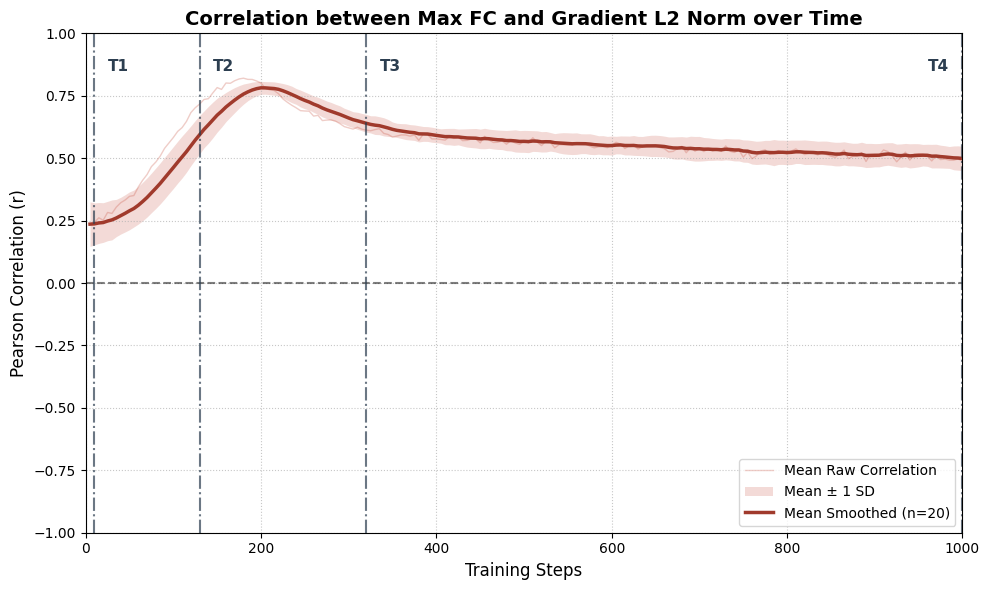

In [4]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import random
import warnings

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10):
        super(MLP, self).__init__()
        self.linear_layers = nn.ModuleList()
        layers = []
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(nn.ReLU())
            current_dim = h_dim
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

def load_standard_mnist():
    print("正在加载 MNIST 数据集...")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    return torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)

def create_train_loader(train_dataset, batch_size=256, seed=0):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)

def collect_balanced_eval_samples(train_dataset, samples_per_class=50):
    eval_samples = []
    class_counts = {i: 0 for i in range(10)}
    for image, label in train_dataset:
        label = int(label)
        if class_counts[label] < samples_per_class:
            eval_samples.append(image)
            class_counts[label] += 1
        if all(count >= samples_per_class for count in class_counts.values()):
            break
    return torch.stack(eval_samples)

def train_and_track_correlation(model, train_loader, eval_samples, max_steps=1000, record_interval=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    eval_samples = eval_samples.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.05)

    step_count = 0
    steps_recorded = []
    correlations = []

    print(f"开始训练，总步数：{max_steps}，每 {record_interval} 步记录一次相关性...")
    model.train()

    while step_count < max_steps:
        for data, targets in train_loader:
            if step_count >= max_steps:
                break

            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()

            current_step = step_count + 1
            if current_step % record_interval == 0:
                layer1_grad = model.linear_layers[0].weight.grad.detach()
                grad_l2 = torch.norm(layer1_grad, p=2, dim=1).cpu().numpy()

                model.eval()
                with torch.no_grad():
                    x_flat = eval_samples.view(eval_samples.size(0), -1)
                    h1 = model.linear_layers[0](x_flat)
                    h1_relu = torch.relu(h1).cpu().numpy()
                    fc = np.corrcoef(h1_relu.T)
                    fc = np.nan_to_num(fc)
                    np.fill_diagonal(fc, 0)
                    max_fc = np.max(fc, axis=1)

                if np.std(max_fc) > 0 and np.std(grad_l2) > 0:
                    r, _ = stats.pearsonr(max_fc, grad_l2)
                else:
                    r = 0.0

                steps_recorded.append(current_step)
                correlations.append(r)
                model.train()

            optimizer.step()
            step_count += 1

            if step_count % 100 == 0:
                current_r = correlations[-1] if correlations else 0.0
                print(f"当前训练步数: {step_count}/{max_steps} | 相关系数 r = {current_r:.4f}")

    return steps_recorded, correlations

def exponential_moving_average(values, smooth_weight=0.85):
    smoothed_values = []
    last = values[0] if len(values) > 0 else 0
    for point in values:
        smoothed_value = last * smooth_weight + (1 - smooth_weight) * point
        smoothed_values.append(smoothed_value)
        last = smoothed_value
    return np.asarray(smoothed_values)

def run_multiple_seeds(train_dataset, eval_samples, seeds=range(20), batch_size=256, max_steps=1000, record_interval=5):
    all_correlations = []
    steps = None

    for run_idx, seed in enumerate(seeds):
        print(f"\n{'=' * 60}")
        print(f"正在运行随机种子 {seed}，实验进度：{run_idx + 1}/{len(seeds)}")
        print(f"{'=' * 60}")

        set_seed(seed)
        train_loader = create_train_loader(train_dataset, batch_size=batch_size, seed=seed)
        model = MLP(input_size=784, hidden_dims=[100, 100], num_classes=10)
        current_steps, current_correlations = train_and_track_correlation(
            model, train_loader, eval_samples, max_steps=max_steps, record_interval=record_interval
        )

        if steps is None:
            steps = current_steps
        all_correlations.append(current_correlations)

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return np.asarray(steps), np.asarray(all_correlations)

def plot_correlation_trend(steps, all_correlations, smooth_weight=0.85):
    print("正在绘制 20 个随机种子的平均趋势和误差区间...")

    smoothed_correlations = np.asarray([
        exponential_moving_average(correlations, smooth_weight)
        for correlations in all_correlations
    ])

    raw_mean = np.mean(all_correlations, axis=0)
    smoothed_mean = np.mean(smoothed_correlations, axis=0)
    smoothed_std = np.std(smoothed_correlations, axis=0, ddof=1)
    lower_bound = smoothed_mean - smoothed_std
    upper_bound = smoothed_mean + smoothed_std

    plt.figure(figsize=(10, 6))
    plt.plot(steps, raw_mean, color='#cb5a49', alpha=0.3, linewidth=1, label='Mean Raw Correlation')
    plt.fill_between(steps, lower_bound, upper_bound, color='#cb5a49', alpha=0.22, linewidth=0, label='Mean ± 1 SD')
    plt.plot(steps, smoothed_mean, color='#a03a2c', linewidth=2.5, label=f'Mean Smoothed (n={len(all_correlations)})')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    t_steps = [10, 130, 320, 1000]
    t_labels = ['T1', 'T2', 'T3', 'T4']

    for step, label in zip(t_steps, t_labels):
        if step <= max(steps):
            plt.axvline(x=step, color='#2c3e50', linestyle='-.', alpha=0.7, linewidth=1.5)
            text_x = step - 15 if step == max(steps) else step + 15
            horizontal_alignment = 'right' if step == max(steps) else 'left'
            plt.text(text_x, 0.85, label, color='#2c3e50', fontweight='bold', fontsize=11,
                     horizontalalignment=horizontal_alignment,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Pearson Correlation (r)', fontsize=12)
    plt.title('Correlation between Max FC and Gradient L2 Norm over Time', fontsize=14, fontweight='bold')
    plt.xlim(0, max(steps))
    plt.ylim(-1.0, 1.0)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('./fig/correlation_trend_over_seeds.pdf', format='pdf')
    plt.show()

if __name__ == '__main__':
    seeds = list(range(20))
    train_dataset = load_standard_mnist()
    eval_samples = collect_balanced_eval_samples(train_dataset, samples_per_class=50)

    steps, all_correlations = run_multiple_seeds(
        train_dataset,
        eval_samples,
        seeds=seeds,
        batch_size=256,
        max_steps=1000,
        record_interval=5
    )

    plot_correlation_trend(steps, all_correlations, smooth_weight=0.85)

Loading MNIST...
Training for 300 steps, saving model every 2 steps...
Computing dynamic ablation and metrics...
Plotting dynamic evidence...


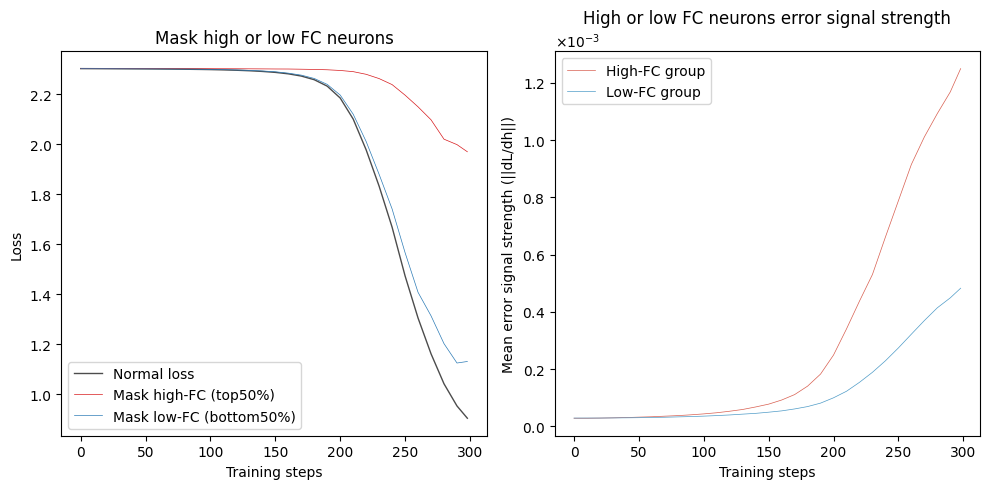

In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10):
        super(MLP, self).__init__()
        self.linear_layers = nn.ModuleList()
        layers = []
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(nn.ReLU())
            current_dim = h_dim
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

    def get_hidden_activations(self, x):
        x = x.view(x.size(0), -1)
        activations = []
        for layer in self.network:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x.clone())
        return activations

def load_standard_mnist(batch_size=256):
    print("Loading MNIST...")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

def train_and_collect(model, train_loader, max_steps=250):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.05)

    model_states, losses = [], []
    print(f"Training for {max_steps} steps, saving model every 2 steps...")
    model.train()

    # 固定评估集（每类50张）
    eval_samples, eval_targets = [], []
    class_counts = {i:0 for i in range(10)}
    for data, targets in train_loader:
        for img, label in zip(data, targets):
            lbl = label.item()
            if class_counts[lbl] < 50:
                eval_samples.append(img)
                eval_targets.append(label)
                class_counts[lbl] += 1
        if len(eval_samples) >= 500:
            break
    eval_samples = torch.stack(eval_samples).to(device)
    eval_targets = torch.tensor(eval_targets).to(device)

    step = 0
    while step < max_steps:
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

            if step % 2 == 0:
                state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                model_states.append(state)

            step += 1
            if step >= max_steps:
                break

    return model_states, losses, eval_samples, eval_targets

def analyze_fc_importance(model_states, losses, eval_samples, eval_targets):
    """
    动态消融 + 指标演化，突出高FC神经元的关键作用
    """
    device = eval_samples.device
    template = MLP(input_size=784, hidden_dims=[100, 100]).to(device)
    # 每10个状态取一个（即每20步），加上第一个和最后一个
    total_states = len(model_states)
    sample_indices = list(range(0, total_states, 5))  # 每10步取一个状态
    if total_states-1 not in sample_indices:
        sample_indices.append(total_states-1)

    steps = [idx*2 for idx in sample_indices]   # 对应的训练步数

    # 存储各项指标
    normal_losses = []
    ablation_high_losses = []
    ablation_low_losses = []
    error_high_means = []
    error_low_means = []
    weight_high_means = []
    weight_low_means = []

    print("Computing dynamic ablation and metrics...")
    for idx in sample_indices:
        state = model_states[idx]
        template.load_state_dict(state)
        template.eval()

        with torch.no_grad():
            act = template.get_hidden_activations(eval_samples)[0].cpu().numpy()
        # 计算FC矩阵
        fc = np.corrcoef(act.T)
        np.fill_diagonal(fc, 0)
        max_fc = np.max(fc, axis=1)
        sorted_indices = np.argsort(max_fc)[::-1]
        high_fc = sorted_indices[:50].tolist()
        low_fc = sorted_indices[-50:].tolist()

        # 正常评估损失
        template.eval()
        with torch.no_grad():
            out = template(eval_samples)
            norm_loss = nn.CrossEntropyLoss()(out, eval_targets).item()
        normal_losses.append(norm_loss)

        # 消融高、低FC神经元后的损失
        x_flat = eval_samples.view(eval_samples.size(0), -1)
        h1 = template.linear_layers[0](x_flat)
        h1_relu = torch.relu(h1)
        remaining_net = template.network[2:]

        def ablate_loss(neuron_list):
            h_abl = h1_relu.clone()
            h_abl[:, neuron_list] = 0.0
            with torch.no_grad():
                out_abl = remaining_net(h_abl)
                loss_abl = nn.CrossEntropyLoss()(out_abl, eval_targets)
            return loss_abl.item()

        ablation_high_losses.append(ablate_loss(high_fc))
        ablation_low_losses.append(ablate_loss(low_fc))

        # 计算误差信号强度（需要梯度）
        template.train()
        x_eval = eval_samples.clone().requires_grad_(False)
        t_eval = eval_targets
        xf = x_eval.view(x_eval.size(0), -1)
        h1_g = template.linear_layers[0](xf)
        h1_relu_g = torch.relu(h1_g)
        out_g = template.network[2:](h1_relu_g)
        loss_g = nn.CrossEntropyLoss()(out_g, t_eval)
        # 修正：只取第一个返回值（h1_relu_g的梯度）
        err_signal = torch.autograd.grad(loss_g, h1_relu_g, create_graph=False, retain_graph=False)[0]
        err_strength = torch.norm(err_signal, p=2, dim=0).cpu().numpy()
        error_high_means.append(err_strength[high_fc].mean())
        error_low_means.append(err_strength[low_fc].mean())

        # 输出权重范数（最后一层线性层到隐层神经元）
        out_weight = template.linear_layers[-1].weight.data.cpu().numpy()   # (10,100)
        out_norm = np.linalg.norm(out_weight, axis=0)
        weight_high_means.append(out_norm[high_fc].mean())
        weight_low_means.append(out_norm[low_fc].mean())

    # ---------- 绘图 ----------
    print("Plotting dynamic evidence...")
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # 图A：训练损失与消融损失对比
    ax1 = axes[0]
    # 原始训练batch损失平滑
    train_smooth = np.convolve(losses, np.ones(20)/20, mode='valid')
    train_steps = np.arange(1, len(losses)+1)[10:][:len(train_smooth)]
    # ax1.plot(train_steps, train_smooth, color='gray', alpha=0.5, label='Training loss (smoothed)')
    ax1.plot(steps, normal_losses, color='black', linewidth=1, alpha=0.7, label='Normal loss')
    ax1.plot(steps, ablation_high_losses, color='#d7191c', linewidth=0.5, label='Mask high-FC (top50%)')
    ax1.plot(steps, ablation_low_losses, color='#2c7bb6', linewidth=0.5, label='Mask low-FC (bottom50%)')
    ax1.set_xlabel('Training steps')
    ax1.set_ylabel('Loss')
    ax1.set_title('Mask high or low FC neurons')
    ax1.legend()
    # ax1.grid(alpha=0.3)

    # 图B：误差信号强度演化
    ax2 = axes[1]
    ax2.plot(steps, error_high_means, color='#d85e4f', linewidth=0.5, label='High-FC group')
    ax2.plot(steps, error_low_means, color='#4e9bc7', linewidth=0.5, label='Low-FC group')
    ax2.set_xlabel('Training steps')
    ax2.set_ylabel('Mean error signal strength (||dL/dh||)')
    ax2.set_title('High or low FC neurons error signal strength')
    ax2.legend()
    # ax2.grid(alpha=0.3)
    ax2.ticklabel_format(style='sci', scilimits=(-3, 3), axis='y', useMathText=True)

    plt.tight_layout()
    plt.savefig('./fig/high_fc_importance_dynamic.pdf', format='pdf', bbox_inches='tight')
    plt.show()

if __name__ == '__main__':
    set_seed(0)
    train_loader = load_standard_mnist(batch_size=256)
    model = MLP(input_size=784, hidden_dims=[100, 100], num_classes=10)
    model_states, losses, eval_samples, eval_targets = train_and_collect(model, train_loader, max_steps=300)
    analyze_fc_importance(model_states, losses, eval_samples, eval_targets)

Loading MNIST Dataset...
Training up to critical step 300...
Analyzing spatial representations (Feature Visualization)...
Plotting feature maps...


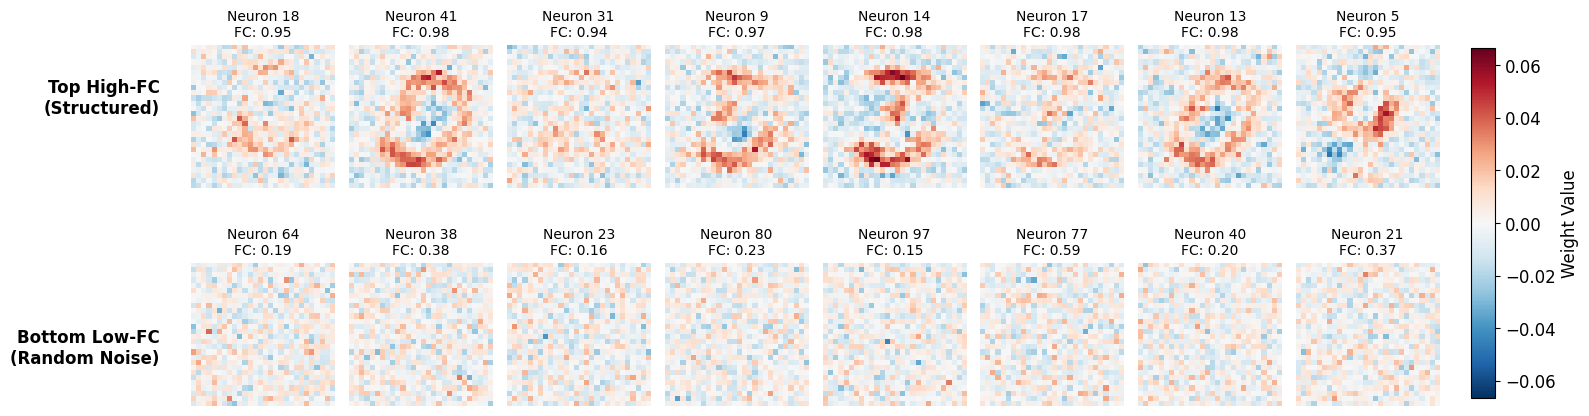

In [99]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10):
        super(MLP, self).__init__()
        self.linear_layers = nn.ModuleList()
        layers = []
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(nn.ReLU())
            current_dim = h_dim
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

    def get_hidden_activations(self, x):
        x = x.view(x.size(0), -1)
        activations = []
        for layer in self.network:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x.clone())
        return activations

def load_standard_mnist(batch_size=256):
    print("Loading MNIST Dataset...")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

def train_to_critical_step(model, train_loader, critical_step=150, lr=0.05):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    print(f"Training up to critical step {critical_step}...")
    model.train()
    
    # 提取固定的500个评估样本用于计算FC
    eval_samples = []
    class_counts = {i: 0 for i in range(10)}
    for data, targets in train_loader:
        for img, label in zip(data, targets):
            lbl = label.item()
            if class_counts[lbl] < 50:
                eval_samples.append(img)
                class_counts[lbl] += 1
        if len(eval_samples) >= 500:
            break
    eval_samples = torch.stack(eval_samples).to(device)
    
    step_count = 0
    # 外层循环确保即使一个 Epoch 的 batch 跑完了，也能继续下一个 Epoch
    while True:
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            # 达到关键步，保存状态并直接返回，彻底跳出所有循环
            if step_count == critical_step:
                critical_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                return critical_state, eval_samples
                
            step_count += 1

def visualize_spatial_features(critical_state, eval_samples):
    print("Analyzing spatial representations (Feature Visualization)...")
    device = eval_samples.device
    template_model = MLP(input_size=784, hidden_dims=[100, 100]).to(device)
    template_model.load_state_dict(critical_state)
    template_model.eval()
    
    # 1. 计算所有神经元的 FC 并排序
    with torch.no_grad():
        act_c = template_model.get_hidden_activations(eval_samples)[0].cpu().numpy()
        fc_critical = np.corrcoef(act_c.T)
        np.fill_diagonal(fc_critical, 0)
        max_fc = np.max(fc_critical, axis=1)
        
    sorted_indices = np.argsort(max_fc)[::-1]
    
    # # 提取最具代表性的 Top 8 和 Bottom 8 神经元
    # top_8_idx = sorted_indices[:8]
    # bottom_8_idx = sorted_indices[-8:]
    
    # 提取 Top 20 和 Bottom 20 神经元的索引
    top_20_idx = sorted_indices[:20]
    bottom_20_idx = sorted_indices[-20:]
    
    # 设置一个局部的随机种子以确保抽样结果固定
    rng = np.random.default_rng(seed=0)
    
    # 从前 20 和后 20 个索引中，无放回地随机挑选 8 个
    top_8_idx = rng.choice(top_20_idx, size=8, replace=False)
    bottom_8_idx = rng.choice(bottom_20_idx, size=8, replace=False)
    
    # 2. 提取第一层权重矩阵 (100, 784)
    first_layer_weights = template_model.linear_layers[0].weight.data.cpu().numpy()
    
    # 3. 绘制权重可视化对比图
    print("Plotting feature maps...")
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    
    # 寻找权重的全局最大绝对值，用于统一颜色条(Colorbar)的比例尺
    # 这样能直观看出高FC权重幅值和低FC权重幅值的差距
    max_val = np.max(np.abs([first_layer_weights[top_8_idx], first_layer_weights[bottom_8_idx]]))
    
    # 绘制 Top 8 高 FC 神经元
    for i, neuron_idx in enumerate(top_8_idx):
        ax = axes[0, i]
        # 将 784 维向量 Reshape 为 28x28 的图像矩阵
        weight_img = first_layer_weights[neuron_idx].reshape(28, 28)
        # 使用 RdBu_r (红-蓝) 颜色映射，红色表示正权重，蓝色表示负权重
        im = ax.imshow(weight_img, cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f'Neuron {neuron_idx}\nFC: {max_fc[neuron_idx]:.2f}', fontsize=10)
        ax.axis('off')
        
    # 绘制 Bottom 8 低 FC 神经元
    for i, neuron_idx in enumerate(bottom_8_idx):
        ax = axes[1, i]
        weight_img = first_layer_weights[neuron_idx].reshape(28, 28)
        im = ax.imshow(weight_img, cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f'Neuron {neuron_idx}\nFC: {max_fc[neuron_idx]:.2f}', fontsize=10)
        ax.axis('off')
        
    # 添加行标题
    fig.text(0.1, 0.75, 'Top High-FC\n(Structured)', va='center', ha='right', fontsize=12, fontweight='bold')
    fig.text(0.1, 0.25, 'Bottom Low-FC\n(Random Noise)', va='center', ha='right', fontsize=12, fontweight='bold')
    
    # 添加全局颜色条
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Weight Value')
    
    plt.subplots_adjust(left=0.12, right=0.9, wspace=0.1, hspace=0.3)
    plt.savefig('./fig/top_bottom_FC_spatial_feature.pdf', format='pdf', bbox_inches='tight')
    plt.show()

if __name__ == '__main__':
    learning_rate = 0.05
    critical_step_idx = 300
    
    set_seed(0)
    train_loader = load_standard_mnist(batch_size=256)
    model = MLP(input_size=784, hidden_dims=[100, 100], num_classes=10)
    
    critical_state, eval_samples = train_to_critical_step(
        model, train_loader, critical_step=critical_step_idx, lr=learning_rate)
    
    visualize_spatial_features(critical_state, eval_samples)